In [5]:
from ultralytics import YOLO

In [6]:
model = YOLO("yolov8n.pt")

model.train(
    data="Dataset/normal_images/data.yaml",
    imgsz=640,
    epochs=2,
    batch=2,
    device="cpu",
    project="Saved_Models",         # your custom folder
    name="elephant_detection_v1"    # training session name
)


New https://pypi.org/project/ultralytics/8.3.235 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.228 🚀 Python-3.10.18 torch-2.9.1 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset/normal_images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=elephant_detection_v12, nbs=64, nms=False, opset=None, 

KeyboardInterrupt: 

In [ ]:
# model = YOLO("yolov8x.pt")   # yolov8m.pt

# results = model.train(
#     data="/Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/Dataset/normal_images/data.yaml",
#     imgsz=1280,
#     epochs=5,
#     batch=8,
#     device='cpu',          # 0 for GPU, 'cpu' for CPU
#     workers=8,
#     patience=20,      
#     optimizer="AdamW",
#     lr0=0.0005,        #  0.001
#     cos_lr=True,
# )


In [4]:
from ultralytics import YOLO

model = YOLO("runs/detect/train5/weights/best.pt")
metrics = model.val()

print(metrics)  


Ultralytics 8.3.228 🚀 Python-3.10.18 torch-2.9.1 CPU (Apple M1)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 258.8±258.7 MB/s, size: 171.2 KB)
val: Scanning /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/Dataset/normal_images/valid/labels.cache... 462 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 462/462 1.1Mit/s 0.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 1.9s/it 54.1s2.0ss
                   all        462        747      0.893      0.912      0.944      0.681
Speed: 0.6ms preprocess, 108.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /Users/yuvrajbhatkariya/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x17b5c9

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train5/weights/best.pt")   

results = model.predict(
    source="test/test1.webp",  
    conf=0.25,                
    save=True                 
)

print("Detection complete! Check the runs/detect/predict folder.")



image 1/1 /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/test/test1.webp: 480x640 3 elephants, 70.7ms
Speed: 6.6ms preprocess, 70.7ms inference, 9.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/yuvrajbhatkariya/runs/detect/predict
Detection complete! Check the runs/detect/predict folder.


In [2]:
from ultralytics import YOLO                             # install  ---> pip install ultralytics
import matplotlib.pyplot as plt                          # install ---> pip install matplotlib
import matplotlib.image as mpimg
import os
from PIL import Image                                    # install  ---> pip install Pillow
import numpy as np                                       #install ---> pip install numpy

MODEL_PATH = "runs/detect/train5/weights/best.pt"        # model ka rlative path
INPUT_IMAGE_PATH = "test/test12.jpeg"                     # teri image ka path dalna
CUSTOM_PROJECT_NAME = "my_display_results"               # run kerne ke baad yaha save hogi prediction images
CUSTOM_RUN_NAME = "side_by_side_test"

CONVERTED_INPUT_PATH = INPUT_IMAGE_PATH.replace('.webp', '.jpg') 
OUTPUT_FORMAT = "jpg" 

print("1. Converting original .webp file to .jpg for compatibility...")
try:
    img = Image.open(INPUT_IMAGE_PATH).convert('RGB')
    img.save(CONVERTED_INPUT_PATH, 'jpeg')
    print(f"   -> Conversion successful. New input file: {CONVERTED_INPUT_PATH}")
except Exception as e:
    print(f"   -> Conversion failed: {e}")
    exit()

model = YOLO(MODEL_PATH)

print("\n2. Running prediction on the converted JPG image...")
results = model.predict(
    source=CONVERTED_INPUT_PATH, 
    conf=0.25,                
    save=True,
    project=CUSTOM_PROJECT_NAME,
    name=CUSTOM_RUN_NAME,
    exist_ok=True,
)

PREDICTED_IMAGE_DIR = os.path.join(CUSTOM_PROJECT_NAME, CUSTOM_RUN_NAME)
PREDICTED_IMAGE_NAME = os.path.basename(CONVERTED_INPUT_PATH) 
PREDICTED_IMAGE_PATH = os.path.join(PREDICTED_IMAGE_DIR, PREDICTED_IMAGE_NAME)
print(f"   -> Predicted image saved to: {PREDICTED_IMAGE_PATH}")


print("\n3. Loading and displaying images side-by-side...")

original_img_pil = Image.open(INPUT_IMAGE_PATH).convert('RGB')
original_img = np.array(original_img_pil)

predicted_img = mpimg.imread(PREDICTED_IMAGE_PATH)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(original_img)
axes[0].set_title(f'Original Image ({os.path.basename(INPUT_IMAGE_PATH)})', fontsize=16)
axes[0].axis('off')

axes[1].imshow(predicted_img)
axes[1].set_title(f'Predicted (YOLO) Image ({os.path.basename(PREDICTED_IMAGE_PATH)})', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nScript finished.")

1. Converting original .webp file to .jpg for compatibility...
   -> Conversion successful. New input file: test/test12.jpeg

2. Running prediction on the converted JPG image...

image 1/1 /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/test/test12.jpeg: 448x640 3 elephants, 49.9ms
Speed: 1.7ms preprocess, 49.9ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/my_display_results/side_by_side_test
   -> Predicted image saved to: my_display_results/side_by_side_test/test12.jpeg

3. Loading and displaying images side-by-side...


FileNotFoundError: [Errno 2] No such file or directory: 'my_display_results/side_by_side_test/test12.jpeg'

Converting input → JPG format...
Converted Image Saved as: test/t9.jpg

Running YOLO prediction...

image 1/1 /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/test/t9.jpg: 640x640 1 elephant, 82.4ms
Speed: 3.9ms preprocess, 82.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/my_display_results/side_by_side_test
Prediction saved at: /Users/yuvrajbhatkariya/data/VScode.C++/Projects/EleVision/my_display_results/side_by_side_test/t9.jpg


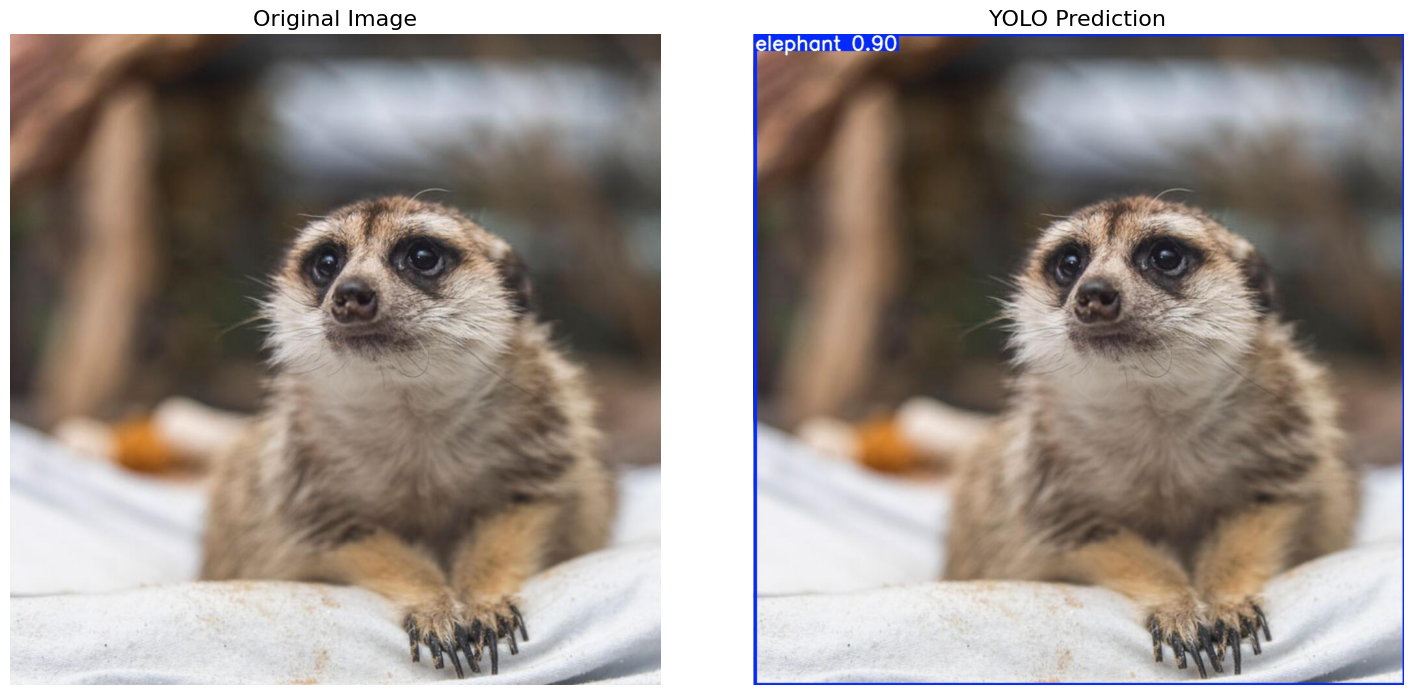


Done!


In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from PIL import Image
import numpy as np

# ---------------------------------------------------
# 1. PATH SETTINGS
# ---------------------------------------------------
MODEL_PATH = "trained_model4/weights/best.pt"
INPUT_IMAGE_PATH = "test/t9.jpg"   # any format: jpeg, jpg, png, webp
CUSTOM_PROJECT_NAME = "my_display_results"
CUSTOM_RUN_NAME = "side_by_side_test"

# ---------------------------------------------------
# 2. Convert input to clean .jpg (Error-proof)
# ---------------------------------------------------
input_name_without_ext = os.path.splitext(INPUT_IMAGE_PATH)[0]
CONVERTED_INPUT_PATH = input_name_without_ext + ".jpg"

print("Converting input → JPG format...")

img = Image.open(INPUT_IMAGE_PATH).convert("RGB")
img.save(CONVERTED_INPUT_PATH, "jpeg")

print(f"Converted Image Saved as: {CONVERTED_INPUT_PATH}")

# ---------------------------------------------------
# 3. Load YOLO model and run prediction
# ---------------------------------------------------
print("\nRunning YOLO prediction...")
model = YOLO(MODEL_PATH)

results = model.predict(
    source=CONVERTED_INPUT_PATH,
    conf=0.60,    # 60,85,70
    save=True,
    project=CUSTOM_PROJECT_NAME,
    name=CUSTOM_RUN_NAME,
    exist_ok=True,
)

# ---------------------------------------------------
# 4. Extract ACTUAL predicted image path from YOLO
# ---------------------------------------------------
save_dir = results[0].save_dir          # folder YOLO used
output_file = os.path.basename(results[0].path)  # YOLO output filename
PREDICTED_IMAGE_PATH = os.path.join(save_dir, output_file)

print(f"Prediction saved at: {PREDICTED_IMAGE_PATH}")

# ---------------------------------------------------
# 5. Load original and predicted images
# ---------------------------------------------------
original_img = np.array(Image.open(INPUT_IMAGE_PATH).convert("RGB"))
predicted_img = mpimg.imread(PREDICTED_IMAGE_PATH)

# ---------------------------------------------------
# 6. Display side-by-side
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(original_img)
axes[0].set_title("Original Image", fontsize=16)
axes[0].axis("off")

axes[1].imshow(predicted_img)
axes[1].set_title("YOLO Prediction", fontsize=16)
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("\nDone!")


In [ ]:
from ultralytics import YOLO
import cv2

# Load your trained model
model = YOLO("trained_model4/weights/best.pt")

# Start webcam
cap = cv2.VideoCapture(0)  # Default webcam

if not cap.isOpened():
    print("Error: Cannot access webcam")
    exit()

CONF_THRESHOLD = 0.80  # 80%

print("Webcam started. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to read frame")
        break

    # YOLO detection with confidence threshold
    results = model(frame, stream=True, conf=CONF_THRESHOLD)

    for r in results:
        for box in r.boxes:
            conf = float(box.conf[0])

            # Skip detections below threshold
            if conf < CONF_THRESHOLD:
                continue

            cls = int(box.cls[0])
            x1, y1, x2, y2 = box.xyxy[0]

            # Label with confidence in %
            label = f"{model.names[cls]} {conf*100:.1f}%"

            # Draw bounding box
            cv2.rectangle(
                frame,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (0, 255, 0),
                2
            )

            # Draw label
            cv2.putText(
                frame,
                label,
                (int(x1), int(y1) - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    # Show frame
    cv2.imshow("YOLOv8 Live Detection (80% Threshold)", frame)

    # FIXED: Correct waitKey line
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Webcam started. Press 'q' to quit.

0: 384x640 (no detections), 65.6ms
Speed: 2.5ms preprocess, 65.6ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 75.8ms
Speed: 1.7ms preprocess, 75.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 44.0ms
Speed: 1.6ms preprocess, 44.0ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 37.5ms
Speed: 1.4ms preprocess, 37.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 38.5ms
Speed: 1.6ms preprocess, 38.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 39.2ms
Speed: 1.6ms preprocess, 39.2ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 86.3ms
Speed: 1.4ms preprocess, 86.3ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 38.0m

KeyboardInterrupt: 

: 

In [4]:
import os

print(os.path.exists("my_display_results/side_by_side_test/test12.jpg"))


True
